--- Starting Analysis of Image Sequence (Cross Pattern) ---
Processing hello1.png...
  Dist between centroids: 87.09, Sum of radii: 48.00,

Processing hello2.png...
  Dist between centroids: 79.10, Sum of radii: 44.00,

Processing hello3.png...
  Dist between centroids: 73.06, Sum of radii: 40.50,

Processing hello4.png...
  Dist between centroids: 67.07, Sum of radii: 37.50,

Processing hello5.png...
  Dist between centroids: 63.07, Sum of radii: 34.50,

Processing hello6.png...
  Dist between centroids: 58.08, Sum of radii: 32.50,

Processing hello7.png...
  Dist between centroids: 55.04, Sum of radii: 31.00,

Processing hello8.png...
  Dist between centroids: 52.09, Sum of radii: 28.50,

Processing hello9.png...
  Dist between centroids: 49.09, Sum of radii: 27.00,

Processing hello10.png...
  Dist between centroids: 47.10, Sum of radii: 26.00,

Processing hello11.png...
  Dist between centroids: 44.05, Sum of radii: 24.50,

Processing hello12.png...
  Dist between centroids: 42.05,

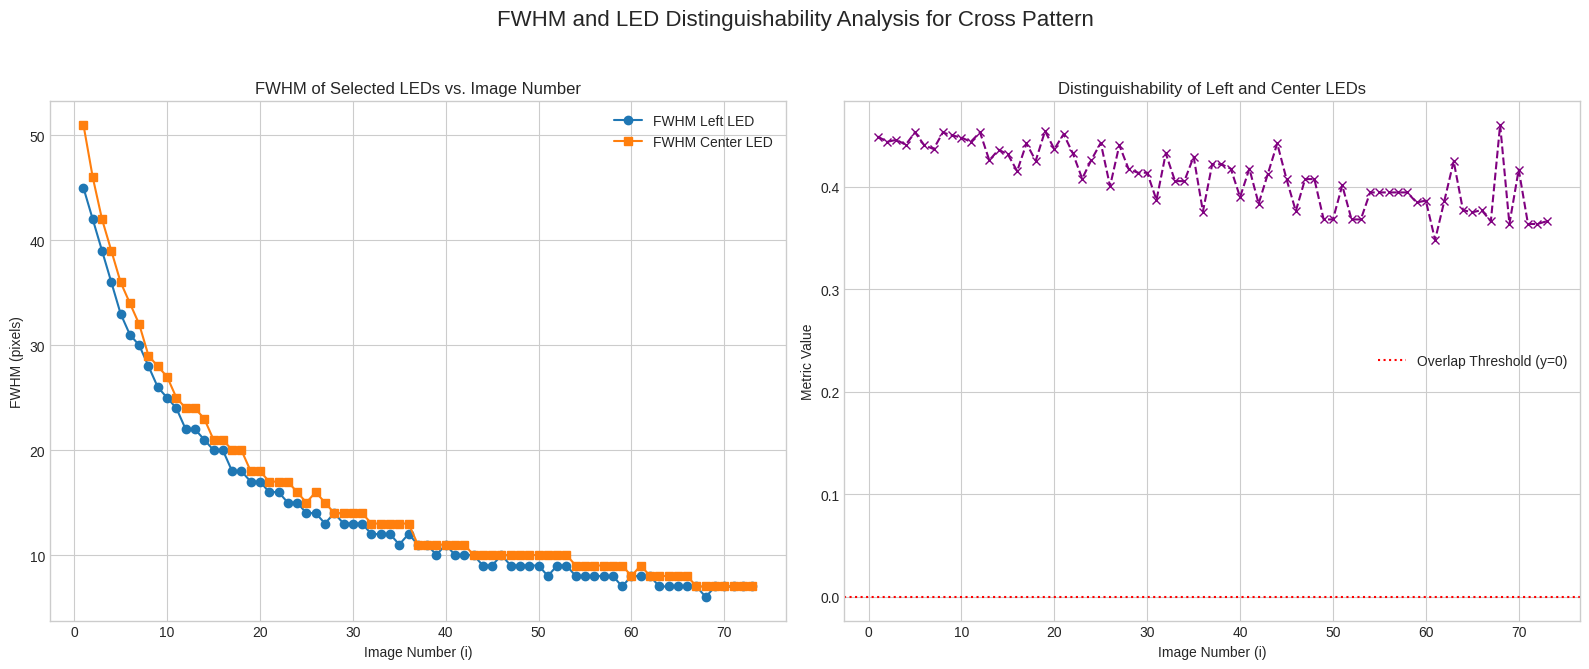

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

def classify_led_pattern(image, filename_for_debug=""):
    """
    Analyzes a grayscale image to find and classify 5 LEDs in a cross pattern.
    This version uses a robust angle-based classification and a more accurate
    localized FWHM calculation to prevent measurement contamination.
    """
    if image is None:
        return {}
        
    gray = image if len(image.shape) == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    if gray.shape[0] > 200 and gray.shape[1] > 200:
        gray = gray[100:-100, 100:-100]

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 70, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    min_contour_area = 10 
    contours = [c for c in contours if cv2.contourArea(c) > min_contour_area]

    if len(contours) != 5:
        print(f"  [DEBUG] For {filename_for_debug}, found {len(contours)} contours. Expected 5.")
        return {}

    all_leds = []
    for c in contours:
        M = cv2.moments(c)
        if M["m00"] == 0: continue
        global_cx = int(M["m10"] / M["m00"])
        global_cy = int(M["m01"] / M["m00"])

        # --- LOCAL FWHM LOGIC START ---
        # 1. Get the bounding box for the contour to create a Region of Interest (ROI)
        x, y, w, h = cv2.boundingRect(c)
        roi_gray = gray[y:y+h, x:x+w]

        # 2. Find max intensity and half-max ONLY within the ROI
        if roi_gray.size == 0: continue
        max_intensity_roi = np.max(roi_gray)
        if max_intensity_roi == 0: continue
        half_max_roi = max_intensity_roi / 2.0

        # 3. Take a horizontal slice through the centroid, but only within the ROI's bounds
        relative_cy = global_cy - y
        relative_cy = max(0, min(h - 1, relative_cy)) # Clamp to be safe
        
        local_profile = roi_gray[relative_cy, :]

        # 4. Calculate FWHM based on this clean, local profile
        above_half_max_indices = np.where(local_profile > half_max_roi)[0]
        
        if above_half_max_indices.size > 0:
            fwhm = len(above_half_max_indices)
            all_leds.append({'cx': global_cx, 'cy': global_cy, 'fwhm': fwhm, 'contour': c})
        # --- LOCAL FWHM LOGIC END ---

    if len(all_leds) != 5:
        print(f"  [DEBUG] Could only process {len(all_leds)} contours into valid LEDs.")
        return {}

    # --- Identify Center and Classify by Angle (This part is correct) ---
    mean_x = np.mean([led['cx'] for led in all_leds])
    mean_y = np.mean([led['cy'] for led in all_leds])
    center_led = min(all_leds, key=lambda led: math.hypot(led['cx'] - mean_x, led['cy'] - mean_y))
    outer_leds = [led for led in all_leds if led != center_led]

    if len(outer_leds) != 4: return {}

    classified_leds = {'Center': center_led}
    for led in outer_leds:
        angle = math.degrees(math.atan2(-(led['cy'] - center_led['cy']), led['cx'] - center_led['cx']))
        if -45 <= angle < 45: classified_leds['Right'] = led
        elif 135 <= angle or angle < -135: classified_leds['Left'] = led
        elif 45 <= angle < 135: classified_leds['Bottom'] = led
        elif -135 <= angle < -45: classified_leds['Top'] = led

    if len(classified_leds) == 5:
        return classified_leds
    else:
        print(f"  [DEBUG] Could not uniquely classify all 4 outer LEDs for {filename_for_debug}.")
        return {}

# --- Main Execution ---
if __name__ == "__main__":
    image_indices, fwhms_led1, fwhms_led3, distinguishability_metrics, r1, r3 = [], [], [], [], [], []

    print("--- Starting Analysis of Image Sequence (Cross Pattern) ---")
    
    i = 1
    while True:
        filename = f"range{i}.png"
        if not os.path.exists(filename):
            if i == 1: # Only print if no files were found at all
                 print(f"Error: Could not find starting file '{filename}'. Make sure script is in the same directory as images.")
            else:
                print(f"File {filename} not found. Ending analysis.")
            break

        print(f"Processing {filename}...")
        image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
        
        leds = classify_led_pattern(image, filename)

        # --- Select LEDs to compare and calculate metric ---
        # We are comparing the 'Left' and 'Center' LEDs.
        if 'Left' in leds and 'Center' in leds:
            led1 = leds['Left']
            led3 = leds['Center'] # This corresponds to your "LED #3"
            
            fwhm1, fwhm3 = led1['fwhm'], led3['fwhm']
            
            dist_centroids = math.hypot(led1['cx'] - led3['cx'], led1['cy'] - led3['cy'])
            
            if dist_centroids > 0:
                # FWHM is diameter, so (fwhm1 + fwhm3)/2 is the sum of radii
                sum_of_radii = (fwhm1 + fwhm3) / 2.0
                print(f"  Dist between centroids: {dist_centroids:.2f}, Sum of radii: {sum_of_radii:.2f},\n")
                metric = (dist_centroids - sum_of_radii) / dist_centroids
            else:
                metric = 0 
                
            image_indices.append(i)
            fwhms_led1.append(fwhm1)
            fwhms_led3.append(fwhm3)
            distinguishability_metrics.append(metric)
            r1.append(fwhm1/(1.0*i))
            r3.append(fwhm3/(1.0*i))
        else:
            print(f"  Warning: Could not identify 5-LED cross pattern in {filename}. Skipping.")
            
        i += 1

    # --- Plotting Results ---
    if not image_indices:
        print("\nNo data was processed. Cannot generate plots.")
    else:
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        # CORRECTED LABELS
        ax1.plot(image_indices, fwhms_led1, marker='o', linestyle='-', label='FWHM Left LED')
        ax1.plot(image_indices, fwhms_led3, marker='s', linestyle='-', label='FWHM Center LED')
        ax1.set_title('FWHM of Selected LEDs vs. Image Number')
        ax1.set_xlabel('Image Number (i)')
        ax1.set_ylabel('FWHM (pixels)')
        ax1.legend()

        ax2.plot(image_indices, distinguishability_metrics, marker='x', linestyle='--', color='purple')
        ax2.axhline(0, color='r', linestyle=':', label='Overlap Threshold (y=0)')
        # CORRECTED TITLE
        ax2.set_title('Distinguishability of Left and Center LEDs')
        ax2.set_xlabel('Image Number (i)')
        ax2.set_ylabel('Metric Value')
        ax2.legend()
        
        fig.suptitle('FWHM and LED Distinguishability Analysis for Cross Pattern', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig('analysis_plot.png')
        print("\nAnalysis complete. Plot saved as 'analysis_plot.png'")
        plt.show()



--- Visual Verification for: hello60.png ---
Pattern identified successfully. Annotating image...
  - LED 'Center': FWHM = 8 pixels
  - LED 'Top': FWHM = 6 pixels
  - LED 'Left': FWHM = 8 pixels
  - LED 'Right': FWHM = 8 pixels
  - LED 'Bottom': FWHM = 8 pixels


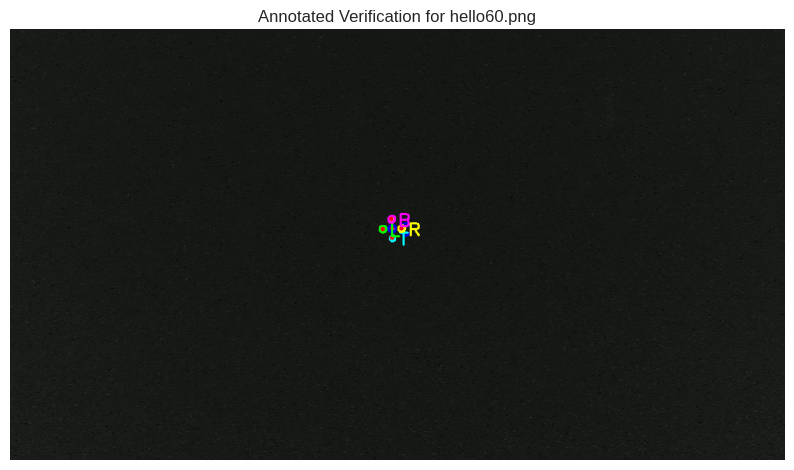

In [ ]:
# This code should be run in a new cell in your Jupyter Notebook,
# *after* you have run the cell containing the 'classify_led_pattern' function.

# --- 1. CONFIGURATION: Set the path to the image you want to check ---
image_path_to_check = "hello60.png" # <--- CHANGE THIS FILENAME

print(f"--- Visual Verification for: {image_path_to_check} ---")

# --- 2. LOAD AND PROCESS THE IMAGE ---
# Load the image in both grayscale (for analysis) and color (for drawing)
single_image_gray = cv2.imread(image_path_to_check, cv2.IMREAD_GRAYSCALE)
single_image_color = cv2.imread(image_path_to_check)

single_image_color = single_image_color[100:-100, 100:-100]


if single_image_gray is None:
    print(f"Error: Could not load the image at '{image_path_to_check}'. Please check the path.")
else:
    # Use the function from the previous cell to get the classified LED data
    leds = classify_led_pattern(single_image_gray, image_path_to_check)

    if not leds:
        print("Verification failed: The 5-LED cross pattern was not identified in this image.")
        # Display the debug image if it was created
        if os.path.exists("debug_contours.png"):
             print("Displaying the debug output from the analysis function:")
             debug_img_display = cv2.imread("debug_contours.png")
             plt.imshow(cv2.cvtColor(debug_img_display, cv2.COLOR_BGR2RGB))
             plt.title("Debug Contours")
             plt.axis('off')
             plt.show()
    else:
        print("Pattern identified successfully. Annotating image...")
        # --- 3. ANNOTATE THE IMAGE ---
        # Define colors for each label
        colors = {
            'Center': (255, 0, 0),   # Blue
            'Left':   (0, 255, 0),   # Green
            'Right':  (0, 255, 255), # Cyan
            'Top':    (255, 255, 0), # Yellow
            'Bottom': (255, 0, 255)  # Magenta
        }

        for label, data in leds.items():
            cx, cy = data['cx'], data['cy']
            fwhm = data['fwhm']
            contour = data['contour']
            
            # Print the FWHM value
            print(f"  - LED '{label}': FWHM = {fwhm} pixels")

            # Draw the contour around the LED
            cv2.drawContours(single_image_color, [contour], -1, colors.get(label, (255,255,255)), 2)
            
            # Draw the red dot for the centroid
            cv2.circle(single_image_color, (cx, cy), 3, (0, 0, 255), -1)
            
            # Add the text label (C, L, R, T, B)
            font = cv2.FONT_HERSHEY_SIMPLEX
            label_text = label[0] # Get the first letter
            cv2.putText(single_image_color, label_text, (cx + 10, cy + 10), font, 0.8, colors.get(label, (255,255,255)), 2)

        # --- 4. DISPLAY THE RESULT ---
        # Convert image from BGR (OpenCV format) to RGB (Matplotlib format) for correct display
        annotated_image_rgb = cv2.cvtColor(single_image_color, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(annotated_image_rgb)
        plt.title(f'Annotated Verification for {image_path_to_check}')
        plt.axis('off')
        plt.savefig('individual.png')
        plt.show()
